In [13]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = r"C:\Users\User\dev\training_model\dataset"
DATASETS = ["dataset_v2.csv", "financial_data.csv", "modified_financial_data.csv"]
MODELS = ["XGB", "RandomForest", "LSTM"]
results = []

In [17]:
def load_data(file_path, dataset_name):
    df = pd.read_csv(file_path)

    if 'Date' in df.columns:
        df = df.drop(columns=['Date'])

    if dataset_name == "dataset_v2.csv":
        target_col = "Close"
    else:
        target_col = "GLD"

    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    df = df.dropna(subset=[target_col])

    y = df[target_col].values
    df = df.drop(columns=[target_col])

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.fillna(df.mean())

    X = df.values
    return X, y


In [6]:
def prepare_lstm_data(X):
    
    return X.reshape((X.shape[0], 1, X.shape[1]))

In [7]:
def train_lstm(X_train, y_train, X_val, y_val):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_data=(X_val, y_val), verbose=0, callbacks=[es])
    return model

In [21]:
for dataset_name in DATASETS:
    print(f"\nProcessing dataset: {dataset_name}")
    file_path = os.path.join(DATA_PATH, dataset_name)
    X, y = load_data(file_path, dataset_name)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

    scaler_X = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # XGB
    xgb = XGBRegressor(random_state=42, verbosity=0)
    xgb.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb.predict(X_test_scaled)
    r2_xgb = r2_score(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    results.append({'Dataset': dataset_name, 'Model': 'XGB', 'R2': r2_xgb, 'MSE': mse_xgb})

    # Random Forest
    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)
    r2_rf = r2_score(y_test, y_pred_rf)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    results.append({'Dataset': dataset_name, 'Model': 'RandomForest', 'R2': r2_rf, 'MSE': mse_rf})

    # LSTM target scaling
    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

    X_train_lstm = prepare_lstm_data(X_train_scaled)
    X_test_lstm = prepare_lstm_data(X_test_scaled)

    lstm_model = train_lstm(X_train_lstm, y_train_scaled, X_test_lstm, y_test_scaled)
    y_pred_lstm_scaled = lstm_model.predict(X_test_lstm).flatten()
    y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

    r2_lstm = r2_score(y_test, y_pred_lstm)
    mse_lstm = mean_squared_error(y_test, y_pred_lstm)
    results.append({'Dataset': dataset_name, 'Model': 'LSTM', 'R2': r2_lstm, 'MSE': mse_lstm})


Processing dataset: dataset_v2.csv


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Processing dataset: financial_data.csv


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Processing dataset: modified_financial_data.csv


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



Results:
                        Dataset         Model        R2          MSE
0                dataset_v2.csv           XGB  0.999395   240.733045
1                dataset_v2.csv  RandomForest  0.999470   210.751943
2                dataset_v2.csv          LSTM  0.996672  1323.773866
15           financial_data.csv           XGB  0.994131     6.855608
16           financial_data.csv  RandomForest  0.996311     4.308791
17           financial_data.csv          LSTM  0.972462    32.166214
18  modified_financial_data.csv           XGB  0.994131     6.855608
19  modified_financial_data.csv  RandomForest  0.996311     4.308997
20  modified_financial_data.csv          LSTM  0.959014    47.874556


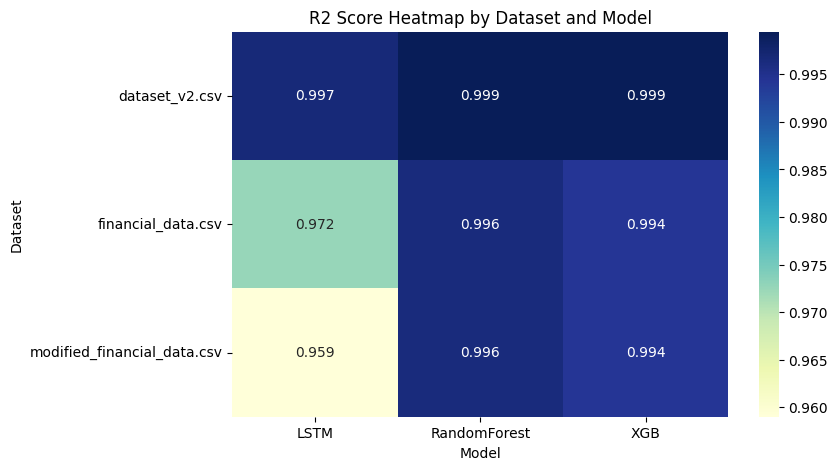

In [22]:
results_df = pd.DataFrame(results)
results_df = results_df.drop_duplicates(subset=['Dataset', 'Model'], keep='first')
print("\nResults:")
print(results_df)

# Pivot table for heatmap (R2 score)
heatmap_data = results_df.pivot(index='Dataset', columns='Model', values='R2')

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("R2 Score Heatmap by Dataset and Model")
plt.show()

Random Forest R2: -0.5617
Random Forest MSE: 995.2863


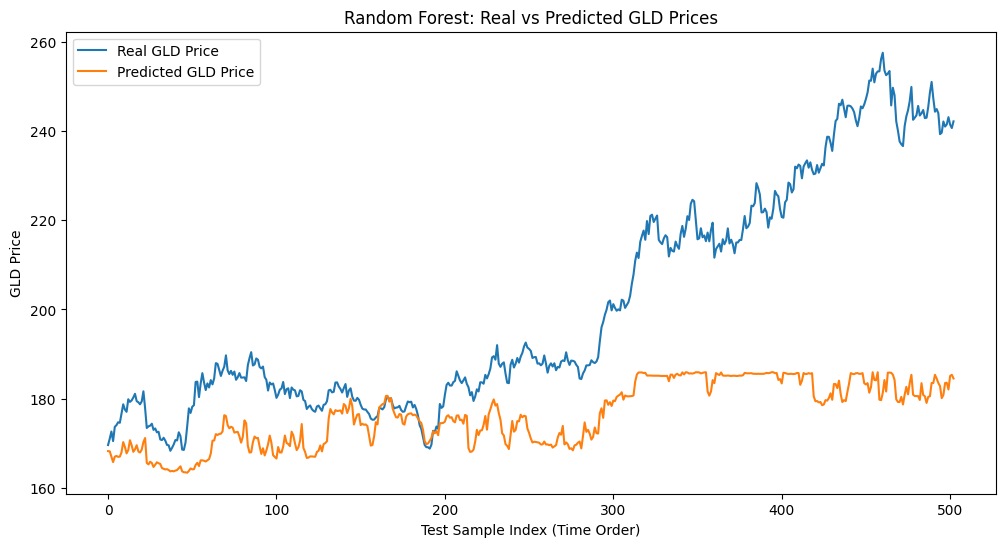

In [23]:
DATA_PATH = r"C:\Users\User\dev\training_model\dataset\modified_financial_data.csv"
df = pd.read_csv(DATA_PATH)

if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

target_col = "GLD"
y = df[target_col].values
X = df.drop(columns=[target_col])

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

y = pd.to_numeric(pd.Series(y), errors='coerce').values

valid_idx = ~np.isnan(y)
X = X.loc[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Random Forest R2: {r2:.4f}")
print(f"Random Forest MSE: {mse:.4f}")


plt.figure(figsize=(12,6))
plt.plot(y_test, label='Real GLD Price')
plt.plot(y_pred, label='Predicted GLD Price')
plt.title("Random Forest: Real vs Predicted GLD Prices")
plt.xlabel("Test Sample Index (Time Order)")
plt.ylabel("GLD Price")
plt.legend()
plt.show()